In [2]:
import h5py
with h5py.File('seen_subjects_test_set/a000_7/data.hdf5', 'r') as f:
    print(list(f.keys()))

['pose', 'raw', 'synced']


In [3]:
with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    print("pose:", list(f['pose'].keys()))
    print("raw:", list(f['raw'].keys()))
    print("synced:", list(f['synced'].keys()))

pose: ['ekf_ori', 'tango_ori', 'tango_pos']
raw: ['imu', 'tango']
synced: ['acce', 'game_rv', 'grav', 'gyro', 'gyro_uncalib', 'linacce', 'magnet', 'rv', 'time']


In [4]:
import h5py

with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    print("acce shape:", f['synced']['acce'].shape)
    print("gyro shape:", f['synced']['gyro'].shape)
    print("magnet shape:", f['synced']['magnet'].shape)
    print("time shape:", f['synced']['time'].shape)
    print("tango_pos shape:", f['pose']['tango_pos'].shape)
    print("tango_ori shape:", f['pose']['tango_ori'].shape)

acce shape: (90054, 3)
gyro shape: (90054, 3)
magnet shape: (90054, 3)
time shape: (90054,)
tango_pos shape: (90054, 3)
tango_ori shape: (90054, 4)


In [5]:
with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    time = f['synced']['time'][:]
    
dt = time[1] - time[0]
sampling_rate = 1 / dt
print("dt:", dt)
print("sampling rate:", sampling_rate)

dt: 0.005000000000109139
sampling rate: 199.99999999563443


In [6]:
with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    tango_pos = f['pose']['tango_pos'][:]

print(tango_pos[:5])

[[ 0.19828247 -0.06767852  0.02137281]
 [ 0.19831425 -0.06757499  0.02142778]
 [ 0.19834742 -0.06747083  0.02148174]
 [ 0.19838156 -0.06736512  0.02153453]
 [ 0.19841774 -0.06725908  0.0215863 ]]


In [7]:
import numpy as np

with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    tango_pos = f['pose']['tango_pos'][:]

dx = np.diff(tango_pos[:, 0])
dy = np.diff(tango_pos[:, 1])

heading = np.arctan2(dy, dx)  # in radians
heading_deg = np.degrees(heading)

print("heading shape:", heading.shape)
print("first 5 heading values (degrees):", heading_deg[:5])
print("min:", heading_deg.min(), "max:", heading_deg.max())

heading shape: (90053,)
first 5 heading values (degrees): [72.93517014 72.33652724 72.10391887 71.15895913 70.78926707]
min: -179.9994267909384 max: 179.9999542547902


In [8]:
sin_heading = np.sin(heading)
cos_heading = np.cos(heading)

print("sin range:", sin_heading.min(), sin_heading.max())
print("cos range:", cos_heading.min(), cos_heading.max())

# verify we can convert back correctly
heading_reconstructed = np.degrees(np.arctan2(sin_heading, cos_heading))
max_reconstruction_error = np.max(np.abs(heading_reconstructed - heading_deg))
print("max reconstruction error (degrees):", max_reconstruction_error)

sin range: -0.9999999996038853 0.9999999999959343
cos range: -0.9999999999996813 0.9999999996977735
max reconstruction error (degrees): 7.105427357601002e-15


In [9]:
with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    acce = f['synced']['acce'][:]
    gyro = f['synced']['gyro'][:]
    magnet = f['synced']['magnet'][:]

# trim first timestep to match heading length
acce = acce[1:]
gyro = gyro[1:]
magnet = magnet[1:]

# stack into single input matrix
X = np.concatenate([acce, gyro, magnet], axis=1)
y = np.column_stack([sin_heading, cos_heading])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("shapes match:", X.shape[0] == y.shape[0])

X shape: (90053, 9)
y shape: (90053, 2)
shapes match: True


In [10]:
def create_windows(X, y, window_size=200, stride=50):
    X_windows = []
    y_windows = []
    
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])  # label is the last timestep of the window
    
    return np.array(X_windows), np.array(y_windows)

X_windows, y_windows = create_windows(X, y)

print("X_windows shape:", X_windows.shape)
print("y_windows shape:", y_windows.shape)

X_windows shape: (1798, 200, 9)
y_windows shape: (1798, 2)


In [11]:
import os

data_folder = 'seen_subjects_test_set'
sequences = os.listdir(data_folder)

all_X = []
all_y = []

for seq in sequences:
    seq_path = os.path.join(data_folder, seq, 'data.hdf5')
    
    with h5py.File(seq_path, 'r') as f:
        acce = f['synced']['acce'][:]
        gyro = f['synced']['gyro'][:]
        magnet = f['synced']['magnet'][:]
        tango_pos = f['pose']['tango_pos'][:]
    
    dx = np.diff(tango_pos[:, 0])
    dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)
    
    acce = acce[1:]
    gyro = gyro[1:]
    magnet = magnet[1:]
    
    X = np.concatenate([acce, gyro, magnet], axis=1)
    y = np.column_stack([np.sin(heading), np.cos(heading)])
    
    X_win, y_win = create_windows(X, y)
    all_X.append(X_win)
    all_y.append(y_win)

all_X = np.concatenate(all_X, axis=0)
all_y = np.concatenate(all_y, axis=0)

print("Total X shape:", all_X.shape)
print("Total y shape:", all_y.shape)

Total X shape: (82656, 200, 9)
Total y shape: (82656, 2)


In [12]:
# compute mean and std per channel
mean = all_X.mean(axis=(0, 1))
std = all_X.std(axis=(0, 1))

print("mean per channel:", mean)
print("std per channel:", std)

# apply normalisation
all_X_norm = (all_X - mean) / std

print("normalised X mean (should be ~0):", all_X_norm.mean(axis=(0, 1)).round(4))
print("normalised X std (should be ~1):", all_X_norm.std(axis=(0, 1)).round(4))

mean per channel: [ 1.78998323e-01  3.48982420e-01  1.38865900e+00  1.47964092e-03
 -9.79954549e-04 -3.67573441e-03 -8.93569779e-01 -1.05971459e+00
 -8.19427008e+00]
std per channel: [ 5.36604785  7.82749308  4.58569045  1.02727385  0.95493056  0.74406322
 27.74819942 38.40384534 34.60059708]
normalised X mean (should be ~0): [-0.  0. -0. -0. -0. -0.  0. -0.  0.]
normalised X std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## script

In [14]:
import h5py
import numpy as np
import os

def create_windows(X, y, window_size=200, stride=50):
    X_windows = []
    y_windows = []
    
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])
    
    return np.array(X_windows), np.array(y_windows)


def load_sequence(seq_path):
    with h5py.File(seq_path, 'r') as f:
        acce = f['synced']['acce'][:]
        gyro = f['synced']['gyro'][:]
        magnet = f['synced']['magnet'][:]
        tango_pos = f['pose']['tango_pos'][:]
    
    dx = np.diff(tango_pos[:, 0])
    dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)
    
    acce = acce[1:]
    gyro = gyro[1:]
    magnet = magnet[1:]
    
    X = np.concatenate([acce, gyro, magnet], axis=1)
    y = np.column_stack([np.sin(heading), np.cos(heading)])
    
    return X, y


def load_dataset(folder):
    all_X = []
    all_y = []
    
    sequences = sorted(os.listdir(folder))
    
    for seq in sequences:
        seq_path = os.path.join(folder, seq, 'data.hdf5')
        if not os.path.exists(seq_path):
            continue
        X, y = load_sequence(seq_path)
        X_win, y_win = create_windows(X, y)
        all_X.append(X_win)
        all_y.append(y_win)
    
    return np.concatenate(all_X, axis=0), np.concatenate(all_y, axis=0)


def preprocess(train_folders, val_folder, test_folder):
    print("Loading training data...")
    X_train_list = []
    y_train_list = []
    for folder in train_folders:
        X, y = load_dataset(folder)
        X_train_list.append(X)
        y_train_list.append(y)
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    
    print("Loading validation data...")
    X_val, y_val = load_dataset(val_folder)
    
    print("Loading test data...")
    X_test, y_test = load_dataset(test_folder)
    
    # compute mean and std on training set only
    print("Normalising...")
    mean = X_train.mean(axis=(0, 1))
    std = X_train.std(axis=(0, 1))
    
    X_train = (X_train - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std
    
    print("Saving arrays to disk...")
    np.save('X_train.npy', X_train)
    np.save('y_train.npy', y_train)
    np.save('X_val.npy', X_val)
    np.save('y_val.npy', y_val)
    np.save('X_test.npy', X_test)
    np.save('y_test.npy', y_test)
    np.save('mean.npy', mean)
    np.save('std.npy', std)
    
    print("Done. All arrays saved.")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, mean, std

# Run commands
train_folders = ['train_dataset_2']
val_folder = 'seen_subjects_test_set'
test_folder = 'seen_subjects_test_set'

X_train, y_train, X_val, y_val, X_test, y_test, mean, std = preprocess(
    train_folders, val_folder, test_folder
)

Loading training data...
Loading validation data...
Loading test data...
Normalising...
Saving arrays to disk...
Done. All arrays saved.
X_train: (81713, 200, 9) y_train: (81713, 2)
X_val: (82656, 200, 9) y_val: (82656, 2)
X_test: (82656, 200, 9) y_test: (82656, 2)


In [15]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (81713, 200, 9)
y_train: (81713, 2)
X_val: (82656, 200, 9)
y_val: (82656, 2)
X_test: (82656, 200, 9)
y_test: (82656, 2)


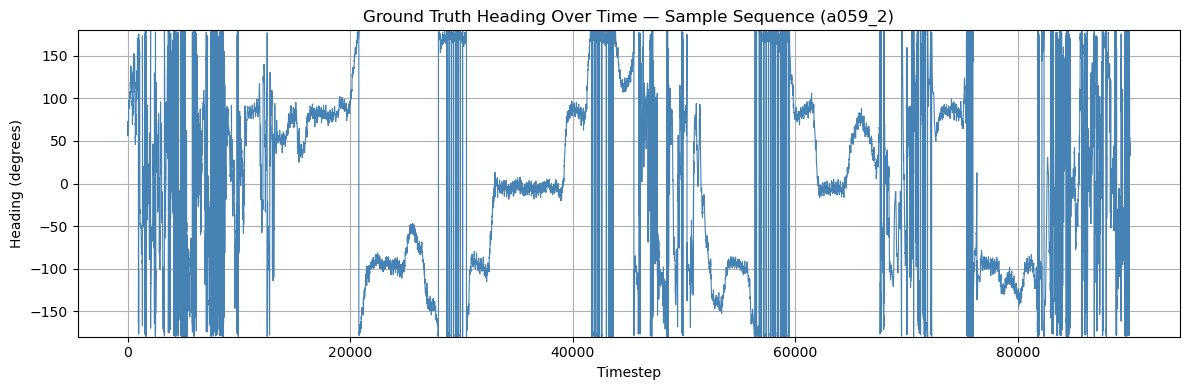

In [16]:
import matplotlib.pyplot as plt

with h5py.File('seen_subjects_test_set/a059_2/data.hdf5', 'r') as f:
    tango_pos = f['pose']['tango_pos'][:]

dx = np.diff(tango_pos[:, 0])
dy = np.diff(tango_pos[:, 1])
heading_deg = np.degrees(np.arctan2(dy, dx))

plt.figure(figsize=(12, 4))
plt.plot(heading_deg, color='steelblue', linewidth=0.8)
plt.title('Ground Truth Heading Over Time — Sample Sequence (a059_2)')
plt.xlabel('Timestep')
plt.ylabel('Heading (degrees)')
plt.ylim(-180, 180)
plt.grid(True)
plt.tight_layout()
plt.savefig('heading_sample.png', dpi=150)
plt.show()